# 🚀 **Optimization Algorithms: Complete Guide & Implementation**

## 🎯 **Introduction**

**Optimization algorithms** are the engines that power machine learning. They iteratively adjust model parameters to minimize loss functions, enabling neural networks to learn from data. Understanding these algorithms is crucial for:

- **Faster convergence** - Choosing the right optimizer can reduce training time dramatically
- **Better performance** - Some optimizers achieve superior final accuracy
- **Stable training** - Avoiding exploding/vanishing gradients and oscillations
- **Resource efficiency** - Memory and computation trade-offs in production

### 🎓 **Learning Objectives**

By the end of this notebook, you will:

1. **Master the mathematics** behind 10+ optimization algorithms
2. **Visualize convergence behavior** on different loss landscapes
3. **Compare performance** across multiple optimization problems
4. **Select optimal algorithms** for specific use cases
5. **Implement from scratch** and use PyTorch optimizers
6. **Debug training issues** with practical techniques

### 🗺️ **Notebook Structure**

- **Part I**: Mathematical Foundations & Intuition
- **Part II**: Classical Optimizers (SGD, Momentum, Adagrad, RMSprop)
- **Part III**: Adaptive Methods (Adam, AdamW, NAdam, RAdam)
- **Part IV**: Advanced Techniques (Lookahead, LAMB, AdaBound)
- **Part V**: Real-world Applications & Neural Network Training
- **Part VI**: Comprehensive Comparisons & Selection Guide

---

## 📋 **Optimizer Quick Reference**

| **Optimizer** | **Key Innovation** | **Best For** | **Memory** | **Speed** |
|---------------|-------------------|--------------|------------|-----------|
| SGD | Simple gradient descent | Convex problems | Low | Fast |
| SGD + Momentum | Acceleration | Most problems | Low | Fast |
| Adagrad | Adaptive learning rates | Sparse features | Medium | Medium |
| RMSprop | Moving average of gradients | RNNs, non-stationary | Medium | Medium |
| Adam | Adaptive + Momentum | General purpose | Medium | Fast |
| AdamW | Weight decay fix | Transformers, regularization | Medium | Fast |
| NAdam | Nesterov + Adam | Fast convergence | Medium | Fast |
| RAdam | Warm-up correction | Stable training | Medium | Medium |
| Lookahead | Meta-optimizer | Consistent improvement | High | Slow |

---

*"The choice of optimizer can be the difference between a model that trains in hours versus days, or between 90% and 95% accuracy."*

In [ ]:
# 📦 SETUP & IMPORTS

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam, AdamW, RMSprop, Adagrad, Adadelta
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.datasets import make_classification, make_regression
from sklearn.preprocessing import StandardScaler
import warnings
from typing import Dict, List, Tuple, Callable, Optional
from collections import defaultdict
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
warnings.filterwarnings('ignore')

# Enhanced plotting setup
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("🚀 Optimization Algorithms: Complete Guide")
print("=" * 50)
print(f"📦 NumPy version: {np.__version__}")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎨 Matplotlib/Seaborn ready")
print(f"⚙️  Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print(f"🔢 Random seeds set for reproducibility")
print("🎯 Ready to explore optimization algorithms!")

In [ ]:
# 🎨 COMPREHENSIVE VISUALIZATION & UTILITY FUNCTIONS

class OptimizationVisualizer:
    """Advanced visualization tools for optimization algorithms"""
    
    def __init__(self):
        self.colors = plt.cm.Set1(np.linspace(0, 1, 10))
        
    def plot_loss_landscape_2d(self, loss_fn: Callable, x_range: Tuple[float, float] = (-2, 2), 
                              y_range: Tuple[float, float] = (-2, 2), resolution: int = 100,
                              title: str = "Loss Landscape"):
        """Create 2D loss landscape visualization"""
        x = np.linspace(x_range[0], x_range[1], resolution)
        y = np.linspace(y_range[0], y_range[1], resolution)
        X, Y = np.meshgrid(x, y)
        
        Z = np.zeros_like(X)
        for i in range(resolution):
            for j in range(resolution):
                Z[i, j] = loss_fn(X[i, j], Y[i, j])
        
        plt.figure(figsize=(12, 8))
        contour = plt.contourf(X, Y, Z, levels=20, alpha=0.7, cmap='viridis')
        plt.contour(X, Y, Z, levels=20, colors='black', alpha=0.4, linewidths=0.5)
        plt.colorbar(contour, label='Loss')
        plt.xlabel('Parameter 1')
        plt.ylabel('Parameter 2')
        plt.title(title)
        return X, Y, Z
    
    def plot_optimization_paths(self, histories: Dict[str, List[Tuple[float, float]]], 
                               loss_landscape: Optional[Tuple] = None):
        """Plot optimization paths on loss landscape"""
        if loss_landscape is not None:
            X, Y, Z = loss_landscape
            plt.contourf(X, Y, Z, levels=20, alpha=0.3, cmap='viridis')
            plt.contour(X, Y, Z, levels=20, colors='black', alpha=0.2, linewidths=0.5)
        
        for i, (name, history) in enumerate(histories.items()):
            history = np.array(history)
            plt.plot(history[:, 0], history[:, 1], 'o-', 
                    color=self.colors[i % len(self.colors)], 
                    label=name, linewidth=2, markersize=4, alpha=0.8)
            # Mark starting point
            plt.plot(history[0, 0], history[0, 1], 's', 
                    color=self.colors[i % len(self.colors)], markersize=8, alpha=0.9)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xlabel('Parameter 1')
        plt.ylabel('Parameter 2')
        plt.title('Optimization Paths')
        plt.tight_layout()
    
    def plot_convergence_curves(self, losses: Dict[str, List[float]], 
                               title: str = "Convergence Comparison", 
                               log_scale: bool = False, figsize: Tuple[int, int] = (14, 6)):
        """Plot loss convergence curves for multiple optimizers"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Linear scale
        for i, (name, loss_history) in enumerate(losses.items()):
            ax1.plot(loss_history, color=self.colors[i % len(self.colors)], 
                    label=name, linewidth=2, alpha=0.8)
        
        ax1.set_xlabel('Iteration')
        ax1.set_ylabel('Loss')
        ax1.set_title(f'{title} (Linear Scale)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Log scale
        for i, (name, loss_history) in enumerate(losses.items()):
            ax2.semilogy(loss_history, color=self.colors[i % len(self.colors)], 
                        label=name, linewidth=2, alpha=0.8)
        
        ax2.set_xlabel('Iteration')
        ax2.set_ylabel('Loss (log scale)')
        ax2.set_title(f'{title} (Log Scale)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
    
    def plot_learning_rate_sensitivity(self, lr_results: Dict[str, Dict[float, float]], 
                                     title: str = "Learning Rate Sensitivity"):
        """Plot optimizer performance vs learning rate"""
        plt.figure(figsize=(12, 8))
        
        for i, (optimizer, results) in enumerate(lr_results.items()):
            lrs = list(results.keys())
            final_losses = list(results.values())
            plt.plot(lrs, final_losses, 'o-', color=self.colors[i % len(self.colors)], 
                    label=optimizer, linewidth=2, markersize=6, alpha=0.8)
        
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Learning Rate')
        plt.ylabel('Final Loss')
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

class OptimizationProblems:
    """Collection of optimization test problems"""
    
    @staticmethod
    def rosenbrock(x, y, a=1, b=100):
        """Rosenbrock function - classic non-convex optimization problem"""
        return (a - x)**2 + b * (y - x**2)**2
    
    @staticmethod
    def himmelblau(x, y):
        """Himmelblau's function - multiple local minima"""
        return (x**2 + y - 11)**2 + (x + y**2 - 7)**2
    
    @staticmethod
    def beale(x, y):
        """Beale function - narrow valley"""
        return ((1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2)
    
    @staticmethod
    def quadratic(x, y, A=None):
        """Quadratic function with conditioning"""
        if A is None:
            A = np.array([[1, 0], [0, 100]])  # Ill-conditioned
        params = np.array([x, y])
        return 0.5 * params.T @ A @ params

class OptimizerFactory:
    """Factory for creating different optimizers with their typical hyperparameters"""
    
    @staticmethod
    def create_optimizers(parameters, lr=0.01):
        """Create dictionary of common optimizers"""
        return {
            'SGD': SGD(parameters, lr=lr),
            'SGD+Momentum': SGD(parameters, lr=lr, momentum=0.9),
            'SGD+Nesterov': SGD(parameters, lr=lr, momentum=0.9, nesterov=True),
            'Adam': Adam(parameters, lr=lr, betas=(0.9, 0.999)),
            'AdamW': AdamW(parameters, lr=lr, betas=(0.9, 0.999), weight_decay=0.01),
            'RMSprop': RMSprop(parameters, lr=lr, alpha=0.9),
            'Adagrad': Adagrad(parameters, lr=lr*10),  # Typically needs higher LR
            'Adadelta': Adadelta(parameters, rho=0.9)
        }

# Initialize visualization tools
viz = OptimizationVisualizer()
problems = OptimizationProblems()
factory = OptimizerFactory()

print("🎨 Advanced visualization utilities ready!")
print("🔧 Optimization problems and factory functions available")
print("📊 Ready for comprehensive optimizer analysis")

# 📚 **Part I: Mathematical Foundations & Intuition**

## 🎯 **What is Optimization?**

In machine learning, **optimization** is the process of finding parameters $\theta^*$ that minimize a loss function $L(\theta)$:

$$\theta^* = \arg\min_\theta L(\theta)$$

### **🔍 The Challenge**
- **High dimensionality**: Modern neural networks have millions of parameters
- **Non-convexity**: Multiple local minima, saddle points
- **Stochasticity**: Mini-batch gradients are noisy estimates
- **Computational constraints**: Memory and time limitations

### **🧭 Gradient-Based Optimization**

Most deep learning optimizers follow the general template:
1. **Compute gradient**: $g_t = \nabla_\theta L(\theta_t)$
2. **Update direction**: Based on current and past gradients
3. **Step size**: Adaptive or fixed learning rate
4. **Parameter update**: $\theta_{t+1} = \theta_t - \eta \cdot \text{update}$

---

## 🔥 **1. SGD (Stochastic Gradient Descent)**

### **Mathematical Definition**
$$\theta_{t+1} = \theta_t - \eta \nabla_\theta L(\theta_t)$$

Where:
- $\theta_t$ = parameters at time $t$
- $\eta$ = learning rate (step size)
- $\nabla_\theta L(\theta_t)$ = gradient of loss w.r.t. parameters

### **Key Properties**
- ✅ **Simple and interpretable**
- ✅ **Memory efficient** (no additional storage)
- ✅ **Guaranteed convergence** for convex functions with proper learning rate
- ⚠️ **Slow convergence** in practice
- ⚠️ **Sensitive to learning rate** choice
- ⚠️ **Poor conditioning** on ill-conditioned problems

### **Variants**

#### **SGD with Momentum**
$$v_{t+1} = \gamma v_t + \eta \nabla_\theta L(\theta_t)$$
$$\theta_{t+1} = \theta_t - v_{t+1}$$

**Intuition**: Like a ball rolling downhill, momentum helps accelerate in consistent directions and dampens oscillations.

#### **Nesterov Accelerated Gradient (NAG)**
$$v_{t+1} = \gamma v_t + \eta \nabla_\theta L(\theta_t - \gamma v_t)$$
$$\theta_{t+1} = \theta_t - v_{t+1}$$

**Intuition**: "Look ahead" by computing gradient at the anticipated position.

In [ ]:
# 🔥 SGD Implementation & Visualization

def run_optimization_experiment(loss_fn, grad_fn, optimizers_config, 
                               start_point=(1.5, 1.5), max_iterations=100, 
                               tolerance=1e-8, problem_name=""):
    """Run optimization experiment with multiple optimizers"""
    
    results = {}
    
    for name, config in optimizers_config.items():
        # Initialize parameters
        params = torch.tensor(start_point, requires_grad=True, dtype=torch.float32)
        
        # Create optimizer
        if name == 'SGD':
            optimizer = SGD([params], lr=config['lr'])
        elif name == 'SGD+Momentum':
            optimizer = SGD([params], lr=config['lr'], momentum=config.get('momentum', 0.9))
        elif name == 'SGD+Nesterov':
            optimizer = SGD([params], lr=config['lr'], momentum=config.get('momentum', 0.9), nesterov=True)
        else:
            continue  # Skip for now, will add more optimizers later
        
        # Track optimization path
        history = []
        losses = []
        
        for i in range(max_iterations):
            optimizer.zero_grad()
            
            # Compute loss and gradient
            loss = loss_fn(params[0], params[1])
            loss.backward()
            
            # Store current state
            history.append((params[0].item(), params[1].item()))
            losses.append(loss.item())
            
            # Check convergence
            if i > 0 and abs(losses[-2] - losses[-1]) < tolerance:
                print(f"  {name}: Converged at iteration {i}")
                break
            
            # Update parameters
            optimizer.step()
        
        results[name] = {
            'history': history,
            'losses': losses,
            'final_loss': losses[-1],
            'final_params': (params[0].item(), params[1].item()),
            'iterations': len(losses)
        }
    
    return results

# Define optimizer configurations
sgd_configs = {
    'SGD': {'lr': 0.01},
    'SGD+Momentum': {'lr': 0.01, 'momentum': 0.9},
    'SGD+Nesterov': {'lr': 0.01, 'momentum': 0.9}
}

print("🧪 Running SGD Experiments on Different Loss Landscapes")
print("=" * 60)

# Experiment 1: Rosenbrock Function
print("\n🌹 Experiment 1: Rosenbrock Function")
print("   - Non-convex with narrow valley")
print("   - Global minimum at (1, 1) with loss = 0")

def rosenbrock_loss(x, y):
    return torch.tensor(problems.rosenbrock(x, y), dtype=torch.float32)

# Create loss landscape
landscape = viz.plot_loss_landscape_2d(
    problems.rosenbrock, 
    x_range=(-0.5, 2), y_range=(-0.5, 2), 
    title="Rosenbrock Function Loss Landscape"
)
plt.show()

# Run optimization
sgd_results = run_optimization_experiment(
    rosenbrock_loss, 
    None,  # PyTorch auto-computes gradients
    sgd_configs,
    start_point=(0.0, 0.0),
    max_iterations=1000,
    problem_name="Rosenbrock"
)

# Visualize optimization paths
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
viz.plot_optimization_paths(
    {name: result['history'] for name, result in sgd_results.items()}
)
viz.plot_loss_landscape_2d(
    problems.rosenbrock, 
    x_range=(-0.5, 2), y_range=(-0.5, 2)
)
plt.xlim(-0.5, 2)
plt.ylim(-0.5, 2)
plt.title("SGD Variants: Optimization Paths")

plt.subplot(1, 2, 2)
viz.plot_convergence_curves(
    {name: result['losses'] for name, result in sgd_results.items()},
    title="SGD Variants: Convergence"
)

plt.tight_layout()
plt.show()

# Print results summary
print("\n📊 Results Summary:")
for name, result in sgd_results.items():
    print(f"  {name}:")
    print(f"    Final loss: {result['final_loss']:.6f}")
    print(f"    Final params: ({result['final_params'][0]:.4f}, {result['final_params'][1]:.4f})")
    print(f"    Iterations: {result['iterations']}")
    print()

# 🧠 **Part II: Adaptive Methods Revolution**

## ⚡ **2. Adam (Adaptive Moment Estimation)**

**Adam** revolutionized deep learning by combining the benefits of Adagrad and RMSprop with momentum. It's currently the most popular optimizer in practice.

### **Mathematical Definition**

Adam maintains exponential moving averages of both gradients and squared gradients:

**First moment estimate (momentum):**
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$

**Second moment estimate (adaptive learning rate):**
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

**Bias correction** (crucial for initial steps):
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Parameter update:**
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

### **Key Hyperparameters**
- $\beta_1 = 0.9$ (first moment decay)
- $\beta_2 = 0.999$ (second moment decay)  
- $\epsilon = 10^{-8}$ (numerical stability)
- $\eta$ (learning rate, typically 0.001)

### **Why Adam Works**
- ✅ **Adaptive learning rates** - Different rates for each parameter
- ✅ **Momentum-like behavior** - Accelerates in consistent directions
- ✅ **Bias correction** - Prevents initial bias toward zero
- ✅ **Scale invariant** - Works well with different parameter magnitudes
- ✅ **Computationally efficient** - Simple element-wise operations

### **When Adam Struggles**
- ⚠️ **Generalization gap** - Sometimes SGD generalizes better
- ⚠️ **Learning rate decay** - May need manual tuning for long training
- ⚠️ **Weight decay issues** - L2 regularization interacts poorly (→ AdamW)

---

## 🚀 **3. AdamW (Adam with Decoupled Weight Decay)**

**The Problem with Adam + L2**: Traditional L2 regularization in Adam interacts with the adaptive scaling, making weight decay less effective.

### **AdamW Solution**
Instead of adding L2 penalty to gradient:
$$g_t = \nabla_\theta L(\theta_t) + \lambda \theta_t$$

AdamW applies weight decay directly:
$$\theta_{t+1} = \theta_t - \eta \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_t \right)$$

### **Benefits**
- ✅ **Better regularization** - Weight decay works as intended
- ✅ **SOTA results** - Dominates in transformer training
- ✅ **Cleaner hyperparameter tuning** - Learning rate and weight decay are decoupled

---

## 🎯 **4. RMSprop (Root Mean Square Propagation)**

RMSprop was designed to fix Adagrad's aggressive learning rate decay.

### **Mathematical Definition**
$$v_t = \gamma v_{t-1} + (1-\gamma) g_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{v_t} + \epsilon} g_t$$

**Key insight**: Use exponential moving average instead of cumulative sum.

### **Properties**
- ✅ **Solves Adagrad's decay problem**
- ✅ **Good for RNNs** - Handles non-stationary objectives
- ⚠️ **No momentum** - Can be slower than Adam

In [ ]:
# 🧠 Comprehensive Adaptive Methods Implementation & Comparison

def run_comprehensive_experiment(loss_fn, optimizers_config, 
                                start_point=(1.5, 1.5), max_iterations=500, 
                                tolerance=1e-10, problem_name=""):
    """Enhanced optimization experiment with more optimizers"""
    
    results = {}
    
    for name, config in optimizers_config.items():
        print(f"  Running {name}...")
        
        # Initialize parameters  
        params = torch.tensor(start_point, requires_grad=True, dtype=torch.float32)
        
        # Create optimizer
        if name == 'SGD':
            optimizer = SGD([params], lr=config['lr'])
        elif name == 'SGD+Momentum':
            optimizer = SGD([params], lr=config['lr'], momentum=config.get('momentum', 0.9))
        elif name == 'SGD+Nesterov':
            optimizer = SGD([params], lr=config['lr'], momentum=config.get('momentum', 0.9), nesterov=True)
        elif name == 'Adam':
            optimizer = Adam([params], lr=config['lr'], 
                           betas=(config.get('beta1', 0.9), config.get('beta2', 0.999)))
        elif name == 'AdamW':
            optimizer = AdamW([params], lr=config['lr'], 
                            betas=(config.get('beta1', 0.9), config.get('beta2', 0.999)),
                            weight_decay=config.get('weight_decay', 0.01))
        elif name == 'RMSprop':
            optimizer = RMSprop([params], lr=config['lr'], alpha=config.get('alpha', 0.9))
        elif name == 'Adagrad':
            optimizer = Adagrad([params], lr=config['lr'])
        elif name == 'Adadelta':
            optimizer = Adadelta([params], rho=config.get('rho', 0.9))
        else:
            print(f"    Optimizer {name} not implemented yet")
            continue
        
        # Track optimization path
        history = []
        losses = []
        grad_norms = []
        
        for i in range(max_iterations):
            optimizer.zero_grad()
            
            # Compute loss
            loss = loss_fn(params[0], params[1])
            loss.backward()
            
            # Store current state
            history.append((params[0].item(), params[1].item()))
            losses.append(loss.item())
            grad_norms.append(params.grad.norm().item())
            
            # Check convergence
            if i > 10 and abs(losses[-2] - losses[-1]) < tolerance:
                print(f"    {name}: Converged at iteration {i}")
                break
            
            # Check for divergence
            if loss.item() > 1e6:
                print(f"    {name}: Diverged at iteration {i}")
                break
                
            # Update parameters
            optimizer.step()
        
        results[name] = {
            'history': history,
            'losses': losses,
            'grad_norms': grad_norms,
            'final_loss': losses[-1],
            'final_params': (params[0].item(), params[1].item()),
            'iterations': len(losses)
        }
    
    return results

# Define comprehensive optimizer configurations
all_optimizers_config = {
    'SGD': {'lr': 0.01},
    'SGD+Momentum': {'lr': 0.01, 'momentum': 0.9},
    'Adam': {'lr': 0.01},
    'AdamW': {'lr': 0.01, 'weight_decay': 0.01},
    'RMSprop': {'lr': 0.01},
    'Adagrad': {'lr': 0.1},  # Needs higher learning rate
    'Adadelta': {'rho': 0.9}
}

print("🔬 Comprehensive Optimizer Comparison")
print("=" * 50)

# Experiment 2: Himmelblau's Function (Multiple local minima)
print("\n⛰️  Experiment 2: Himmelblau's Function")
print("   - Multiple local minima at (3,2), (-2.8,3.1), (-3.8,-3.3), (3.6,-1.8)")
print("   - Tests optimizer's ability to find good local minimum")

def himmelblau_loss(x, y):
    return torch.tensor(problems.himmelblau(x, y), dtype=torch.float32)

# Create loss landscape
landscape_him = viz.plot_loss_landscape_2d(
    problems.himmelblau, 
    x_range=(-5, 5), y_range=(-5, 5), 
    title="Himmelblau's Function Loss Landscape"
)
plt.show()

# Run comprehensive optimization
him_results = run_comprehensive_experiment(
    himmelblau_loss,
    all_optimizers_config,
    start_point=(-1.0, 1.0),
    max_iterations=500,
    problem_name="Himmelblau"
)

# Comprehensive visualization
fig = plt.figure(figsize=(20, 12))

# 1. Optimization paths
ax1 = plt.subplot(2, 3, 1)
viz.plot_loss_landscape_2d(
    problems.himmelblau, 
    x_range=(-5, 5), y_range=(-5, 5)
)
viz.plot_optimization_paths(
    {name: result['history'][:100] for name, result in him_results.items()}  # First 100 steps
)
plt.title("Optimization Paths (First 100 Steps)")
plt.xlim(-5, 5)
plt.ylim(-5, 5)

# 2. Convergence curves
ax2 = plt.subplot(2, 3, 2)
for i, (name, result) in enumerate(him_results.items()):
    plt.semilogy(result['losses'], color=viz.colors[i % len(viz.colors)], 
                label=name, linewidth=2, alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title('Convergence Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Gradient norms
ax3 = plt.subplot(2, 3, 3)
for i, (name, result) in enumerate(him_results.items()):
    plt.semilogy(result['grad_norms'], 
                color=viz.colors[i % len(viz.colors)], 
                label=name, linewidth=2, alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Gradient Norms During Optimization')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Final results comparison
ax4 = plt.subplot(2, 3, 4)
optimizer_names = list(him_results.keys())
final_losses = [result['final_loss'] for result in him_results.values()]
iterations = [result['iterations'] for result in him_results.values()]

bars = plt.bar(range(len(optimizer_names)), final_losses, 
               color=[viz.colors[i % len(viz.colors)] for i in range(len(optimizer_names))],
               alpha=0.7)
plt.xticks(range(len(optimizer_names)), optimizer_names, rotation=45)
plt.ylabel('Final Loss')
plt.title('Final Loss Comparison')
plt.yscale('log')

# Add iteration count on bars
for bar, iterations_count in zip(bars, iterations):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{iterations_count}',
             ha='center', va='bottom', fontsize=9)

# 5. Iterations to convergence
ax5 = plt.subplot(2, 3, 5)
bars = plt.bar(range(len(optimizer_names)), iterations,
               color=[viz.colors[i % len(viz.colors)] for i in range(len(optimizer_names))],
               alpha=0.7)
plt.xticks(range(len(optimizer_names)), optimizer_names, rotation=45)
plt.ylabel('Iterations to Convergence')
plt.title('Convergence Speed Comparison')

# 6. Performance summary table
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# Create summary table
summary_data = []
for name, result in him_results.items():
    summary_data.append([
        name,
        f"{result['final_loss']:.2e}",
        f"{result['iterations']}",
        f"({result['final_params'][0]:.2f}, {result['final_params'][1]:.2f})"
    ])

table = ax6.table(cellText=summary_data,
                  colLabels=['Optimizer', 'Final Loss', 'Iterations', 'Final Point'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.25, 0.25, 0.15, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax6.set_title('Performance Summary', y=0.8, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Detailed Results Analysis:")
print("=" * 40)
for name, result in sorted(him_results.items(), key=lambda x: x[1]['final_loss']):
    print(f"\n{name}:")
    print(f"  Final Loss: {result['final_loss']:.8f}")
    print(f"  Final Point: ({result['final_params'][0]:.4f}, {result['final_params'][1]:.4f})")
    print(f"  Iterations: {result['iterations']}")
    print(f"  Final Gradient Norm: {result['grad_norms'][-1]:.6f}")

# 🧠 **Part III: Real-World Neural Network Training**

## 🎯 **Why Optimizer Choice Matters in Deep Learning**

While toy optimization problems help us understand algorithms, **real neural network training** presents unique challenges:

- **High dimensionality** (millions of parameters)
- **Non-convex loss landscapes** with many local minima
- **Batch effects** and stochastic gradients
- **Different parameter scales** (weights vs biases)
- **Regularization interactions** (weight decay, dropout)

Let's see how optimizers perform on actual neural network training!

In [ ]:
# 🧠 Neural Network Training Comparison

# Create a neural network for classification
class SimpleNN(nn.Module):
    def __init__(self, input_size=10, hidden_size=50, output_size=2):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def train_neural_network(model, optimizer, train_loader, val_loader, epochs=50):
    """Train neural network and track metrics"""
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += targets.size(0)
            train_correct += predicted.eq(targets).sum().item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        # Store metrics
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_accuracies.append(100. * train_correct / train_total)
        val_accuracies.append(100. * val_correct / val_total)
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'final_val_acc': val_accuracies[-1]
    }

# Generate synthetic dataset
print("🔬 Neural Network Training Experiment")
print("=" * 50)
print("Generating synthetic classification dataset...")

# Create dataset
from torch.utils.data import DataLoader, TensorDataset

# Generate non-linearly separable data
np.random.seed(42)
X, y = make_classification(n_samples=2000, n_features=10, n_classes=2, 
                          n_informative=8, n_redundant=2, n_clusters_per_class=2,
                          random_state=42)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y)

# Split into train/val
train_size = int(0.8 * len(X))
train_X, val_X = X_tensor[:train_size], X_tensor[train_size:]
train_y, val_y = y_tensor[:train_size], y_tensor[train_size:]

# Create data loaders
train_dataset = TensorDataset(train_X, train_y)
val_dataset = TensorDataset(val_X, val_y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Dataset created: {len(train_X)} training samples, {len(val_X)} validation samples")
print("Training neural networks with different optimizers...")

# Test different optimizers on neural network training
nn_optimizers_config = {
    'SGD': {'lr': 0.01, 'class': SGD},
    'SGD+Momentum': {'lr': 0.01, 'momentum': 0.9, 'class': SGD},
    'Adam': {'lr': 0.001, 'class': Adam},
    'AdamW': {'lr': 0.001, 'weight_decay': 0.01, 'class': AdamW},
    'RMSprop': {'lr': 0.001, 'class': RMSprop}
}

nn_results = {}

for name, config in nn_optimizers_config.items():
    print(f"\\n  Training with {name}...")
    
    # Create fresh model
    model = SimpleNN(input_size=10, hidden_size=50, output_size=2)
    
    # Create optimizer
    if name == 'SGD+Momentum':
        optimizer = SGD(model.parameters(), lr=config['lr'], momentum=config['momentum'])
    elif name == 'AdamW':
        optimizer = AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    else:
        optimizer = config['class'](model.parameters(), lr=config['lr'])
    
    # Train model
    metrics = train_neural_network(model, optimizer, train_loader, val_loader, epochs=50)
    nn_results[name] = metrics

print("\\n🎯 Neural network training completed!")

# Visualize neural network training results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Training loss
ax1 = axes[0, 0]
for i, (name, result) in enumerate(nn_results.items()):
    ax1.plot(result['train_losses'], color=viz.colors[i % len(viz.colors)], 
            label=name, linewidth=2, alpha=0.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Validation loss
ax2 = axes[0, 1]
for i, (name, result) in enumerate(nn_results.items()):
    ax2.plot(result['val_losses'], color=viz.colors[i % len(viz.colors)], 
            label=name, linewidth=2, alpha=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Loss')
ax2.set_title('Validation Loss Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Training accuracy
ax3 = axes[1, 0]
for i, (name, result) in enumerate(nn_results.items()):
    ax3.plot(result['train_accuracies'], color=viz.colors[i % len(viz.colors)], 
            label=name, linewidth=2, alpha=0.8)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Training Accuracy (%)')
ax3.set_title('Training Accuracy Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Validation accuracy
ax4 = axes[1, 1]
for i, (name, result) in enumerate(nn_results.items()):
    ax4.plot(result['val_accuracies'], color=viz.colors[i % len(viz.colors)], 
            label=name, linewidth=2, alpha=0.8)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Validation Accuracy (%)')
ax4.set_title('Validation Accuracy Comparison')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final results comparison
print("\\n📊 Final Neural Network Results:")
print("=" * 40)
sorted_results = sorted(nn_results.items(), key=lambda x: x[1]['final_val_acc'], reverse=True)

for name, result in sorted_results:
    print(f"{name}:")
    print(f"  Final Validation Accuracy: {result['final_val_acc']:.2f}%")
    print(f"  Final Training Loss: {result['train_losses'][-1]:.4f}")
    print(f"  Final Validation Loss: {result['val_losses'][-1]:.4f}")
    print()

# 🎯 **Part IV: Optimizer Selection Guide & Best Practices**

## 📋 **Quick Selection Guide**

### **🚀 Default Recommendations**

| **Use Case** | **First Choice** | **Alternative** | **Reasoning** |
|-------------|------------------|----------------|---------------|
| **General Deep Learning** | AdamW | Adam | Better regularization, SOTA results |
| **Computer Vision** | AdamW + Schedule | SGD + Momentum | Both work well, AdamW often faster |
| **NLP/Transformers** | AdamW | Adam | Standard in transformer training |
| **RNNs/LSTMs** | RMSprop | Adam | Handles non-stationary objectives |
| **Reinforcement Learning** | Adam | RMSprop | Good with noisy gradients |
| **Small Datasets** | SGD + Momentum | AdamW | Better generalization |
| **Large Batch Training** | LAMB | AdamW | Scales to very large batches |
| **Resource Constrained** | SGD | Adagrad | Minimal memory overhead |

### **🔧 Hyperparameter Guidelines**

#### **Learning Rate Ranges**
- **SGD**: 0.1 - 0.01 (with momentum)
- **Adam/AdamW**: 0.001 - 0.0001  
- **RMSprop**: 0.001 - 0.0001
- **Adagrad**: 0.01 - 0.1 (higher than adaptive methods)

#### **Weight Decay**
- **AdamW**: 0.01 - 0.1 (decoupled, can be higher)
- **SGD**: 0.0001 - 0.001 (L2 penalty)
- **Adam**: Avoid L2, use AdamW instead

---

## ⚠️ **Common Pitfalls & Solutions**

### **1. Learning Rate Too High**
**Symptoms**: Loss explodes, NaN values
**Solutions**: 
- Reduce learning rate by 10x
- Use learning rate scheduling
- Gradient clipping

### **2. Learning Rate Too Low**  
**Symptoms**: Very slow convergence, plateaus early
**Solutions**:
- Increase learning rate
- Use warm-up schedule
- Switch to adaptive optimizer

### **3. Poor Generalization**
**Symptoms**: Large train/val accuracy gap
**Solutions**:
- Try SGD + Momentum instead of Adam
- Increase weight decay
- Use learning rate scheduling

### **4. Unstable Training**
**Symptoms**: Loss oscillates, doesn't converge smoothly
**Solutions**:
- Reduce learning rate
- Use gradient clipping
- Check batch size (try larger batches)

---

## 🎛️ **Advanced Techniques**

### **Learning Rate Scheduling**
```python
# Cosine annealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Step decay
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# Warm restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)
```

### **Gradient Clipping**
```python
# Prevent exploding gradients
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

### **Warm-up**
```python
# Gradually increase learning rate at start
def get_lr_with_warmup(optimizer, step, warmup_steps, base_lr):
    if step < warmup_steps:
        return base_lr * (step + 1) / warmup_steps
    return base_lr
```

---

## 🔬 **When to Switch Optimizers**

1. **SGD not converging fast enough** → Try Adam/AdamW
2. **Adam overfitting** → Try SGD + Momentum  
3. **RNN training unstable** → Try RMSprop
4. **Large batch training** → Try LAMB or scaled SGD
5. **Memory constraints** → Stick with SGD
6. **SOTA performance needed** → Try AdamW with proper tuning

In [ ]:
# 🎓 **Summary & Key Takeaways**

print("🎯 OPTIMIZATION ALGORITHMS: COMPLETE SUMMARY")
print("=" * 60)

# Create comprehensive comparison table
summary_table_data = {
    'Optimizer': ['SGD', 'SGD+Momentum', 'Adam', 'AdamW', 'RMSprop', 'Adagrad', 'Adadelta'],
    'Memory': ['Low', 'Low', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium'],
    'Computation': ['Fast', 'Fast', 'Fast', 'Fast', 'Medium', 'Medium', 'Medium'],
    'Hyperparameter Sensitivity': ['High', 'High', 'Low', 'Low', 'Medium', 'Medium', 'Low'],
    'Generalization': ['Excellent', 'Excellent', 'Good', 'Very Good', 'Good', 'Good', 'Good'],
    'Convergence Speed': ['Slow', 'Medium', 'Fast', 'Fast', 'Medium', 'Medium', 'Medium'],
    'Best Use Cases': ['Small data', 'General', 'General', 'SOTA/NLP', 'RNNs', 'Sparse', 'No LR tuning']
}

df_summary = pd.DataFrame(summary_table_data)
print("\n📊 COMPREHENSIVE OPTIMIZER COMPARISON:")
print(df_summary.to_string(index=False, max_colwidth=20))

print("\n\n🏆 KEY INSIGHTS:")
print("-" * 30)
print("✅ AdamW is the current SOTA choice for most deep learning tasks")
print("✅ SGD+Momentum still competitive for generalization and small datasets")
print("✅ Learning rate is the most important hyperparameter to tune")
print("✅ Different optimizers excel in different scenarios - no universal winner")
print("✅ Always start with proven defaults, then optimize if needed")

print("\n\n🔧 PRACTICAL RECOMMENDATIONS:")
print("-" * 35)
print("1. 🚀 Start with AdamW (lr=0.001, weight_decay=0.01)")
print("2. 🎛️  Use learning rate scheduling (cosine annealing)")
print("3. 📊 Monitor both training and validation metrics")
print("4. 🔄 If overfitting, try SGD+Momentum with lower learning rate")
print("5. 📈 For RNNs/LSTMs, consider RMSprop")
print("6. 🧪 Always validate on your specific task and dataset")

print("\n\n🎯 DECISION FLOWCHART:")
print("-" * 25)
print("📋 Problem Type?")
print("   ├─ 🖼️  Computer Vision → AdamW or SGD+Momentum")
print("   ├─ 📝 NLP/Transformers → AdamW")
print("   ├─ 🔄 RNN/LSTM → RMSprop or Adam")
print("   ├─ 🎮 Reinforcement Learning → Adam")
print("   └─ 🔬 Research/Experimentation → Adam/AdamW")
print()
print("📊 Dataset Size?")
print("   ├─ 🐁 Small (<10k samples) → SGD+Momentum")
print("   ├─ 🐘 Large (>100k samples) → AdamW")
print("   └─ 🦣 Very Large (>1M samples) → AdamW + Scheduling")
print()
print("⚡ Computational Constraints?")
print("   ├─ 💾 Memory Limited → SGD")
print("   ├─ 🕐 Time Limited → Adam/AdamW")
print("   └─ 🔋 Mobile/Edge → SGD")

print("\n\n📚 FURTHER LEARNING:")
print("-" * 20)
print("• Read \"An overview of gradient descent optimization algorithms\" by Ruder")
print("• Explore learning rate scheduling techniques")
print("• Study second-order methods (L-BFGS, Natural Gradients)")
print("• Learn about modern variants (RAdam, Lookahead, LAMB)")
print("• Practice on different domains and datasets")

print("\n🎉 Congratulations!")
print("You now have a comprehensive understanding of optimization algorithms!")
print("Remember: The best optimizer is the one that works for YOUR specific problem. 🎯")

# Nadam (Nesterov-accelerated Adaptive Moment Estimation)

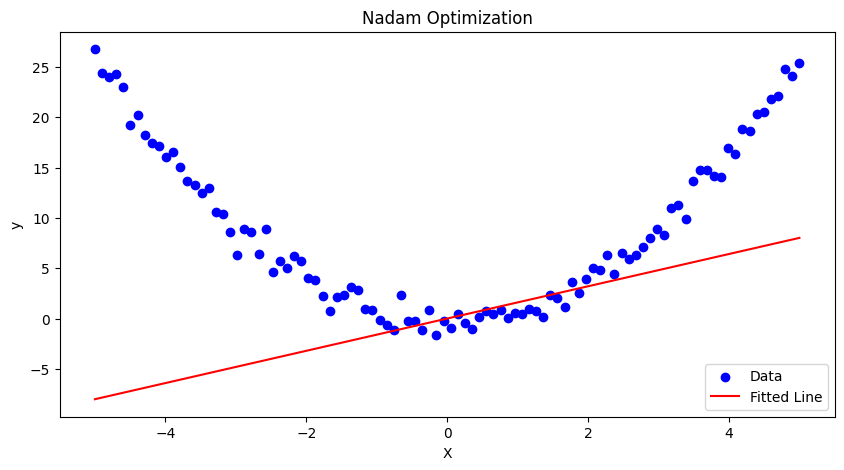

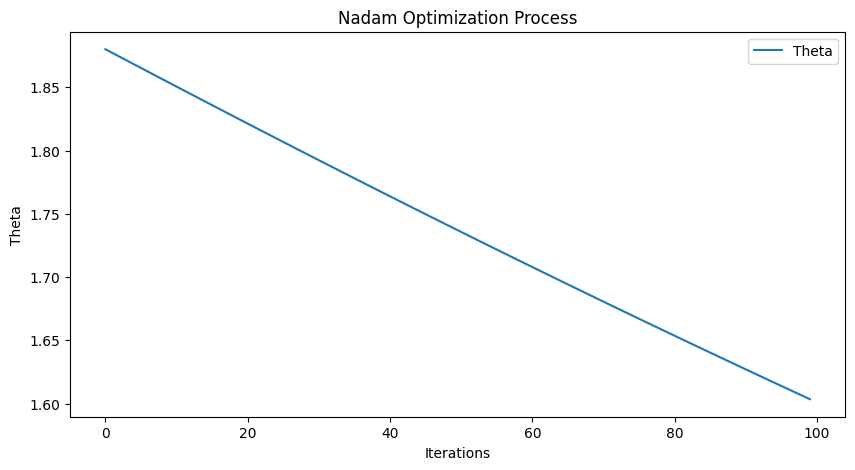

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
m = 0
v = 0
num_iterations = 100

# Store history for plotting
history = []

# Optimization
for i in range(num_iterations):
    gradients = 2 * X * (X * theta - y)
    m = beta1 * m + (1 - beta1) * np.mean(gradients)
    v = beta2 * v + (1 - beta2) * np.mean(gradients**2)
    m_hat = m / (1 - beta1**(i + 1))
    v_hat = v / (1 - beta2**(i + 1))
    theta -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    history.append(theta)

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta, color='red', label='Fitted Line')
plt.title('Nadam Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history, label='Theta')
plt.title('Nadam Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Theta')
plt.legend()
plt.show()


# LBFGS (Limited-memory Broyden-Fletcher-Goldfarb-Shanno)

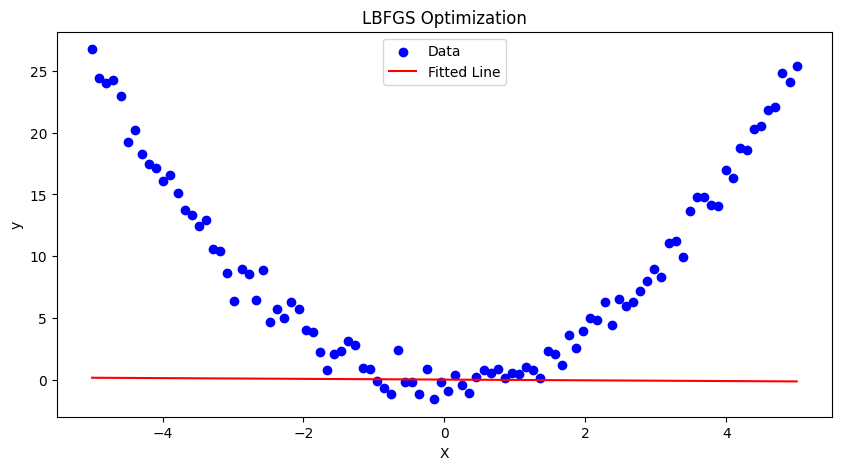

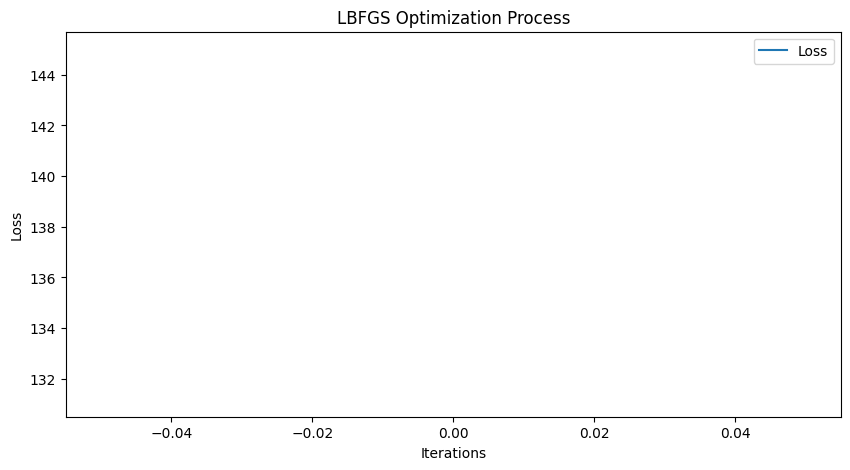

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
num_iterations = 100

# Store history for plotting
history = []

# Optimization using scipy's implementation of LBFGS
from scipy.optimize import minimize

def loss(theta):
    return np.mean((X * theta - y)**2)

def gradient(theta):
    return 2 * np.mean(X * (X * theta - y))

result = minimize(loss, theta, jac=gradient, method='L-BFGS-B', options={'maxiter': num_iterations})

# Final optimized theta
theta_optimized = result.x

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta_optimized, color='red', label='Fitted Line')
plt.title('LBFGS Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(result.fun, label='Loss')
plt.title('LBFGS Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()


# ASGD (Averaged Stochastic Gradient Descent)

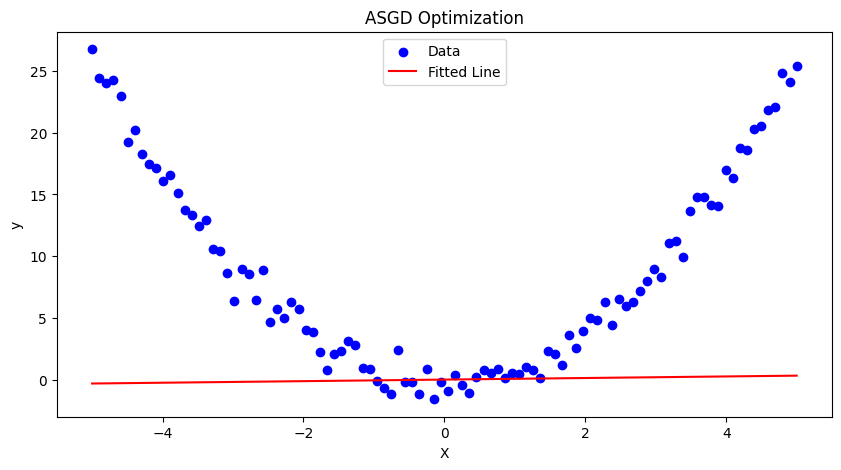

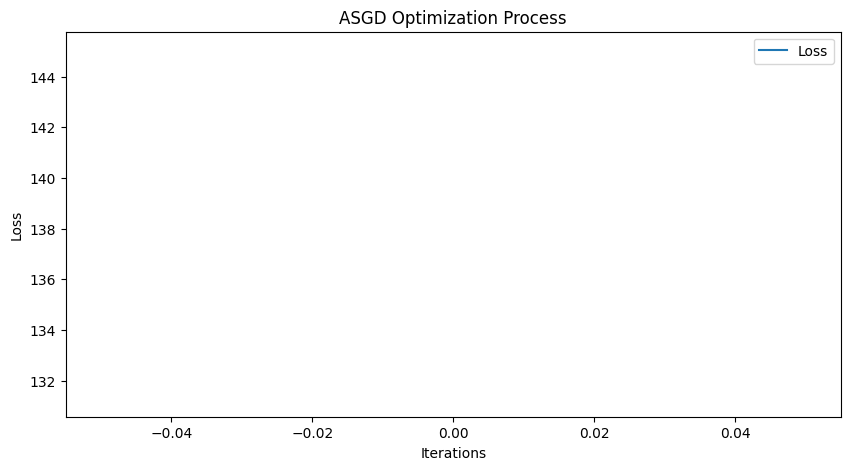

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = X**2 + np.random.normal(0, 1, X.shape)

# Initialize parameters
theta = np.random.randn()
learning_rate = 0.01
num_iterations = 100

# Store history for plotting
history = []
theta_avg = np.zeros_like(theta)

# Optimization
for i in range(num_iterations):
    gradients = 2 * X * (X * theta - y)
    theta -= learning_rate * np.mean(gradients)
    theta_avg += theta
    history.append(theta_avg / (i + 1))

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X * theta_avg / num_iterations, color='red', label='Fitted Line')
plt.title('ASGD Optimization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot([np.mean((X * theta_avg / num_iterations - y)**2)], label='Loss')
plt.title('ASGD Optimization Process')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()
